In [0]:
%pip install git+https://github.com/rasbt/mlxtend.git

  Cloning https://github.com/rasbt/mlxtend.git to /tmp/pip-req-build-c9nbzj1f
  Running command git clone --filter=blob:none --quiet https://github.com/rasbt/mlxtend.git /tmp/pip-req-build-c9nbzj1f
  Resolved https://github.com/rasbt/mlxtend.git to commit 366f717b87f2fcaeeb67b70432b6e1a801519eff
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Load the saved Delta dataset
master_df = spark.read.format("delta").load("dbfs:/Volumes/workspace/default/faers/master_df")

# Quick check
print(f"Rows: {master_df.count()}, Columns: {len(master_df.columns)}")
master_df.show(5, truncate=False)


Rows: 54861, Columns: 7
+--------+------------+---------+------------+---------------------+---+--------+
|caseid  |drugname    |dose_freq|prod_ai     |pt                   |sex|outc_cod|
+--------+------------+---------+------------+---------------------+---+--------+
|16539620|TOPIRAMATE  |QD       |TOPIRAMATE  |Infection            |F  |OT      |
|17953401|PREGABALIN  |BID      |PREGABALIN  |Wheezing             |F  |OT      |
|19165536|BACLOFEN    |Q8H      |BACLOFEN    |Dizziness            |M  |OT      |
|16214741|CYCLOSPORINE|BID      |CYCLOSPORINE|Product storage error|F  |OT      |
|17688373|NAPROXEN    |BID      |NAPROXEN    |Nausea               |F  |OT      |
+--------+------------+---------+------------+---------------------+---+--------+
only showing top 5 rows


In [0]:
# Imports
import pandas as pd
from pyspark.sql import functions as F
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth
from itertools import combinations
import matplotlib.pyplot as plt


In [0]:
# Step 1 — Aggregate cases
case_level = master_df.groupBy("caseid").agg(
    F.collect_set("drugname").alias("drugs"),
    F.collect_set("pt").alias("pts")
)

case_level = case_level.filter(F.size("drugs") >= 2)
case_pd = case_level.toPandas()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/pandas/types.py:931: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  return pser.astype(pandas_type, copy=False)


In [0]:
# Step 2 — Reference lists
master_pd = master_df.toPandas()

pt_values = set(master_pd["pt"].unique())
drug_values = set(master_pd["drugname"].unique())

/databricks/python/lib/python3.12/site-packages/pyspark/sql/pandas/types.py:931: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  return pser.astype(pandas_type, copy=False)


In [0]:
# Step 3 — Build transactions
transactions = []
for _, row in case_pd.iterrows():
    drugs = [d for d in row["drugs"] if d in drug_values]
    pts = [p for p in row["pts"] if p in pt_values]
    
    if len(drugs) >= 2 and len(pts) >= 1:
        transactions.append(drugs + pts)

print("Total transactions:", len(transactions))

Total transactions: 5964


In [0]:
# Step 4 — Encode
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)


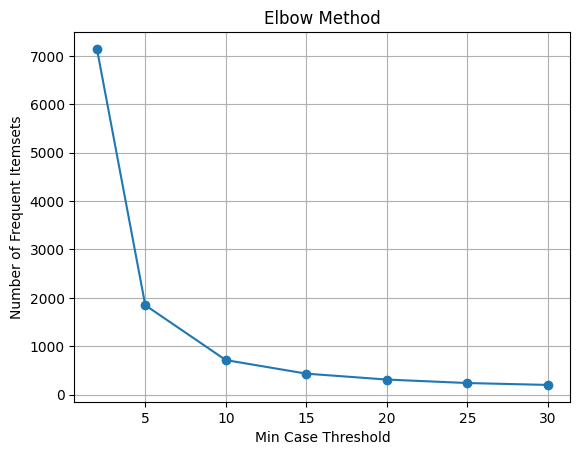

In [0]:
n_trans = len(transactions)
threshold_cases = [2, 5, 10, 15, 20, 25, 30]

itemset_counts = []

for t in threshold_cases:
    min_support = t / n_trans
    
    fi = fpgrowth(
        df_encoded,
        min_support=min_support,
        use_colnames=True
    )
    
    itemset_counts.append(len(fi))

plt.plot(threshold_cases, itemset_counts, marker='o')
plt.xlabel("Min Case Threshold")
plt.ylabel("Number of Frequent Itemsets")
plt.title("Elbow Method")
plt.grid()
plt.show()

In [0]:
# Step 5 — FP-Growth
frequent_itemsets = fpgrowth(
    df_encoded,
    min_support=5/len(transactions),
    use_colnames=True
)


In [0]:
# Keep only 3-itemsets
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)
frequent_itemsets = frequent_itemsets[frequent_itemsets["length"] == 3]


In [0]:
# Step 6 — Split rules (2 drugs → 1 PT)
def split_two_drug_one_pt(itemset):
    drugs = [x for x in itemset if x in drug_values]
    pts = [x for x in itemset if x in pt_values]
    if len(drugs) == 2 and len(pts) == 1:
        return frozenset(drugs), frozenset(pts)
    return None, None

frequent_itemsets["antecedents"], frequent_itemsets["consequents"] = zip(
    *frequent_itemsets["itemsets"].apply(split_two_drug_one_pt)
)

final_rules = frequent_itemsets.dropna(subset=["antecedents", "consequents"])

In [0]:
# Step 7 — Compute metrics
pair_support = {}
for trans in transactions:
    drugs_in_trans = [d for d in trans if d in drug_values]
    for pair in combinations(drugs_in_trans, 2):
        pair = frozenset(pair)
        pair_support[pair] = pair_support.get(pair, 0) + 1

n_trans = len(transactions)

supports, confidences, lifts, case_counts = [], [], [], []

for _, row in final_rules.iterrows():
    ant = row["antecedents"]
    con = list(row["consequents"])[0]

    sup_ABC = row["support"]
    sup_AB = pair_support[ant] / n_trans
    sup_C = sum([1 for t in transactions if con in t]) / n_trans

    conf = sup_ABC / sup_AB if sup_AB > 0 else 0
    lift = conf / sup_C if sup_C > 0 else 0

    supports.append(sup_ABC)
    confidences.append(conf)
    lifts.append(lift)
    case_counts.append(int(sup_ABC * n_trans))

final_rules["support"] = supports
final_rules["confidence"] = confidences
final_rules["lift"] = lifts
final_rules["case_count"] = case_counts


In [0]:
# Step 8 — Outcome processing
# Map outcome codes → labels
outcome_map = {
    "DE": "Critical",
    "LT": "Critical",
    "HO": "Serious",
    "DS": "Serious",
    "CA": "Serious",
    "RI": "Moderate",
    "OT": "Moderate"
}

master_pd["outcome_label"] = master_pd["outc_cod"].map(outcome_map).fillna("Unknown")

# Severity ranking
severity_order = {
    "Critical": 1,
    "Serious": 2,
    "Moderate": 3,
    "Unknown": 4
}

# Count outcomes per PT
pt_counts = master_pd.groupby(["pt", "outcome_label"]).size().reset_index(name="count")

# Function to pick final outcome
def pick_outcome(df):
    max_count = df["count"].max()
    candidates = df[df["count"] == max_count]

    if len(candidates) == 1:
        return candidates["outcome_label"].values[0]
    else:
        candidates = candidates.copy()
        candidates["severity"] = candidates["outcome_label"].map(severity_order)
        return candidates.sort_values("severity", ascending=False)["outcome_label"].values[0]

pt_outcome_final = pt_counts.groupby("pt").apply(pick_outcome).reset_index(name="final_outcome")


In [0]:
# Step 9 — Merge outcome
final_rules["pt"] = final_rules["consequents"].apply(lambda x: list(x)[0])

final_rules = final_rules.merge(pt_outcome_final, how="left", on="pt")

In [0]:
# Step 10 — Final sorting
final_rules = final_rules.sort_values(by=["lift", "confidence"], ascending=False)

In [0]:
# Step 11 — Prepare final result
result = final_rules.copy()


In [0]:
# Convert antecedents and consequents sets to readable strings
result["drug_1"] = result["antecedents"].apply(lambda x: list(x)[0])
result["drug_2"] = result["antecedents"].apply(lambda x: list(x)[1])
result["pt"] = result["consequents"].apply(lambda x: list(x)[0])

# Keep only necessary columns
result = result[[
    "drug_1",
    "drug_2",
    "pt",
    "final_outcome",
    "case_count",
    "support",
    "confidence",
    "lift"
]]

# Round numeric values for clarity
result["support"] = result["support"].round(4)
result["confidence"] = result["confidence"].round(2)
result["lift"] = result["lift"].round(2)



In [0]:
# Step 12 — Save to CSV in workspace directory
output_path = "/Workspace/Users/navoda.20222032@iit.ac.lk/result.csv"
result.to_csv(output_path, index=False)

print(f"CSV saved to: {output_path}")

CSV saved to: /Workspace/Users/navoda.20222032@iit.ac.lk/result.csv


In [0]:

# Optional: Display top 20
result.head(20)

,drug_1,drug_2,pt,final_outcome,case_count,support,confidence,lift
244,VANCOMYCIN,RITUXIMAB,Quadriparesis,Serious,6,0.0010,1.00,852.00
239,PREDNISOLONE,MELATONIN,Epistaxis,Moderate,5,0.0008,0.50,596.40
82,METOCLOPRAMIDE,CYCLOSPORINE,Cardiac failure,Serious,9,0.0015,1.00,542.18
186,ACYCLOVIR,IBUPROFEN,Hepatitis acute,Moderate,5,0.0008,0.71,532.50
245,METOCLOPRAMIDE,PREDNISOLONE,Thrombotic microangiopathy,Moderate,10,0.0017,1.00,497.00
237,RIZATRIPTAN,ZOPICLONE,Dysphonia,Moderate,5,0.0008,0.38,458.77
257,MYCOPHENOLATE MOFETIL,LEVETIRACETAM,Venoocclusive liver disease,Moderate,5,0.0008,0.31,372.75
225,CEFTRIAXONE,LEVETIRACETAM,Purpura,Moderate,9,0.0015,0.50,331.33
132,ACYCLOVIR,AMPHOTERICIN B,Renal tubular disorder,Moderate,10,0.0017,0.53,313.89
36,DIAZEPAM,METHYLPHENIDATE,Pulmonary embolism,Serious,6,0.0010,0.67,165.67


In [0]:
len(result)

258

In [0]:
joined = rules_exploded.crossJoin(case_level).filter(
    (F.array_contains(F.col("drugs"), F.col("drug_1"))) &
    (F.array_contains(F.col("drugs"), F.col("drug_2"))) &
    (F.array_contains(F.col("pts"), F.col("pt")))
)